In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import numpy as np 
import time
import matplotlib.image as mpimg
from mpl_toolkits.mplot3d import Axes3D 

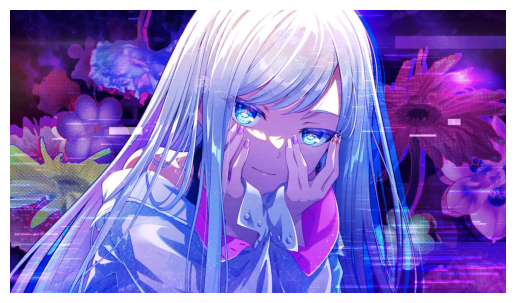

In [54]:
img_path = "D:/Pic/Ceremony_In_The_Classroom_T.png"
img = mpimg.imread(img_path, format=".png")
imgplot = plt.imshow(img)
plt.axis('off')
plt.show() 

In [55]:
print(img.shape)

(571, 1000, 3)


In [56]:
def preprocess(img):
    data = img.reshape((img.shape[0]*img.shape[1], img.shape[2]))
    return data

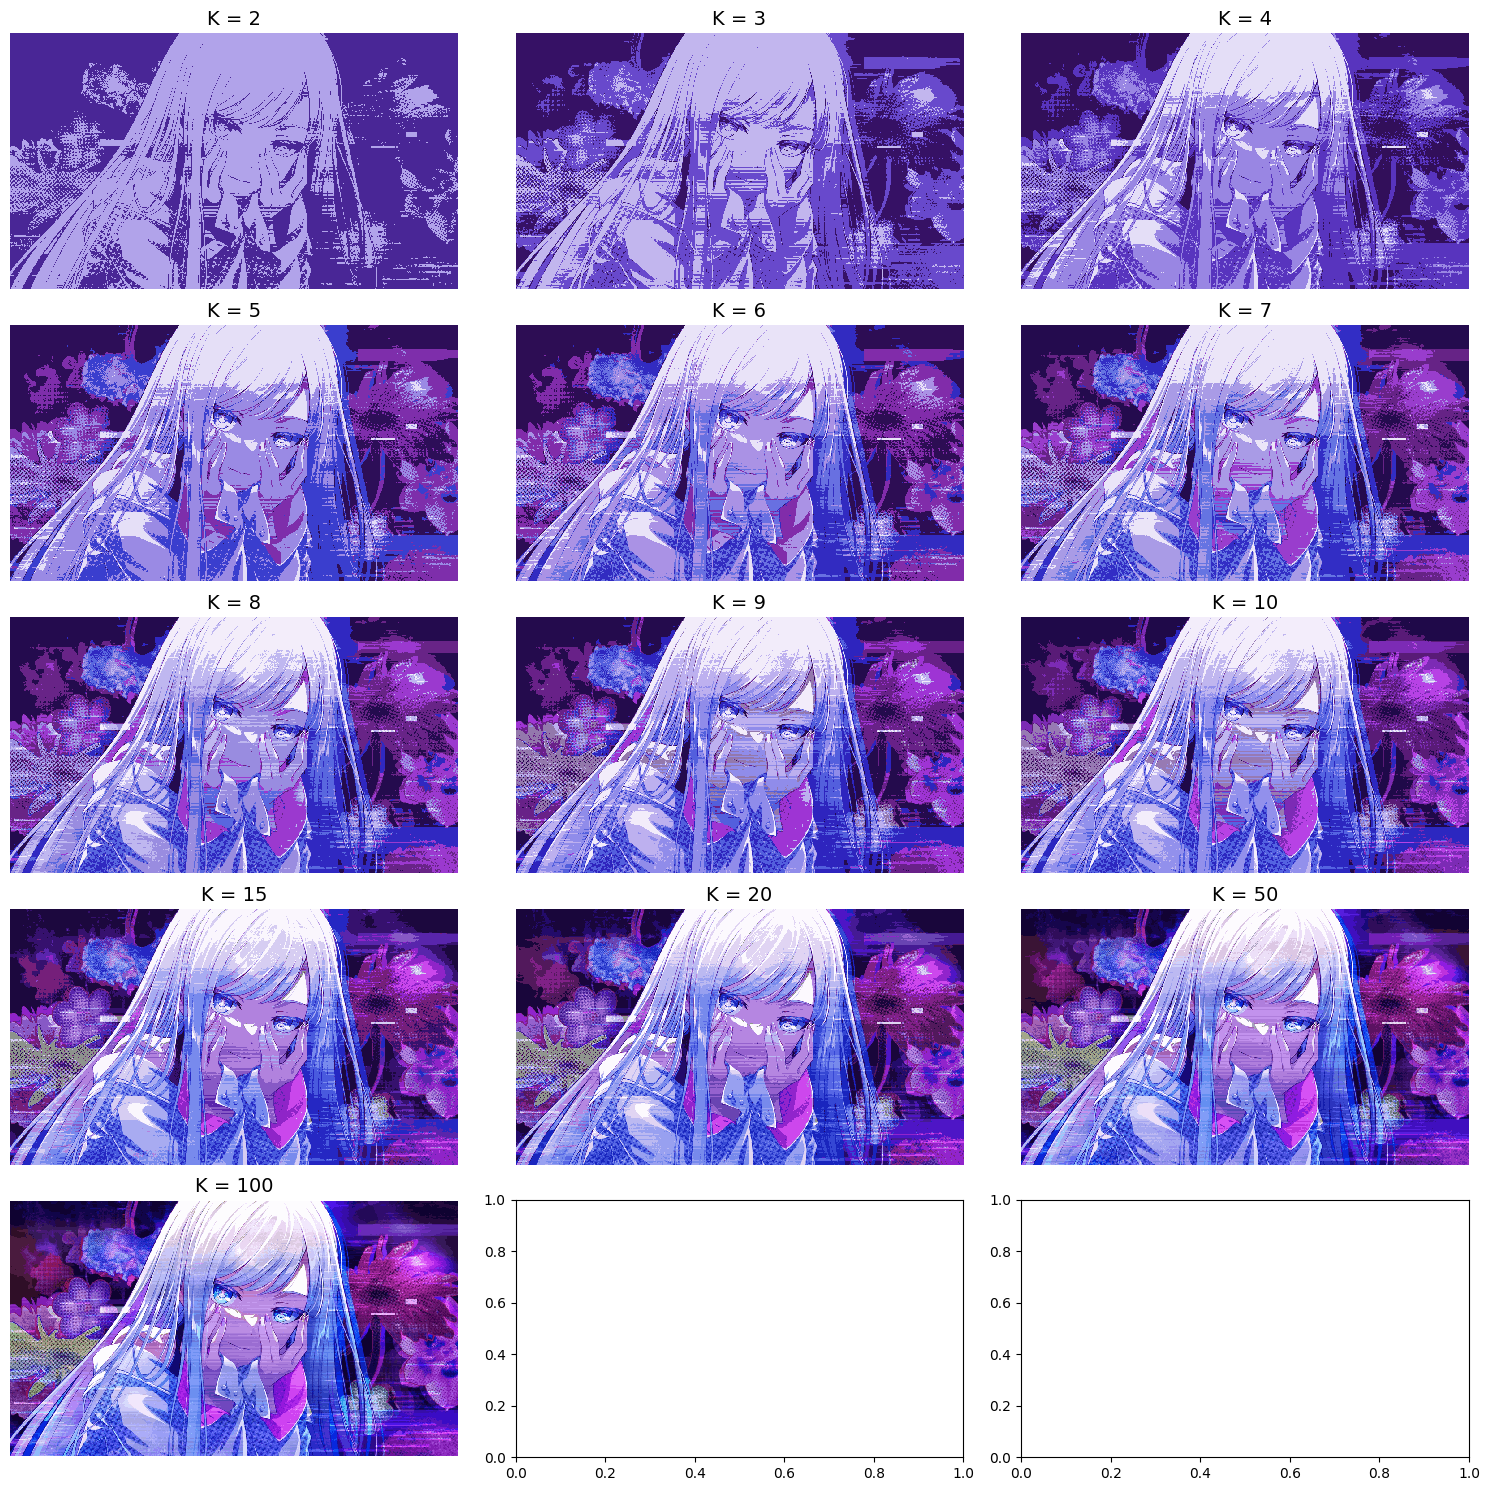

In [57]:
X = preprocess(img)
K_values = [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 50, 100]
n = len(K_values)
col = 3
row = n // 3 + (1 if n%3 != 0 else 0)
fig, axes = plt.subplots(row, col, figsize=(15, 15))
axes = axes.flatten() 
for i, K in enumerate(K_values):
    kmeans = KMeans(n_clusters=K, random_state=1, n_init='auto').fit(X)
    label = kmeans.predict(X)
    img4 = np.zeros_like(X)
    for k in range(K):
        img4[label == k] = kmeans.cluster_centers_[k]
    # Reshape về lại kích thước ảnh ban đầu
    img5 = img4.reshape((img.shape[0], img.shape[1], img.shape[2]))
    # Hiển thị ảnh lên ô thứ i trong lưới
    axes[i].imshow(img5, interpolation='nearest')
    axes[i].set_title(f'K = {K}', fontsize=14)
    axes[i].axis('off')
plt.tight_layout() 
plt.show()

[[ 78.87069009  21.95386078 198.35169894]
 [224.17281587 212.72035619 243.91820397]
 [ 25.46561432   6.97896915  59.55122961]
 [119.04433078 138.95058164 236.51651404]
 [ 25.44012945  37.67391586 190.69842503]
 [105.84479588  68.82558947 178.24960157]
 [205.59903267  71.21971139 237.68744053]
 [252.18265071 249.46452048 254.17147031]
 [ 69.35586044  26.8600741  148.18206245]
 [128.21110389  33.01104613 135.38134431]
 [145.20638472  36.87230551 204.04337286]
 [ 35.99268686  11.99225668 106.87890303]
 [ 87.15689009 103.34300146 229.64262031]
 [187.49902534 185.41980158 241.27339909]
 [144.99473397 149.3932268  142.40257854]
 [152.42242447 160.9713501  240.74058915]
 [181.8883266  134.17839882 225.58895775]
 [ 53.80381608  71.30866136 212.79415893]
 [ 82.70725554  25.17723138  92.94197698]
 [149.54659124  98.46886711 206.68946382]]


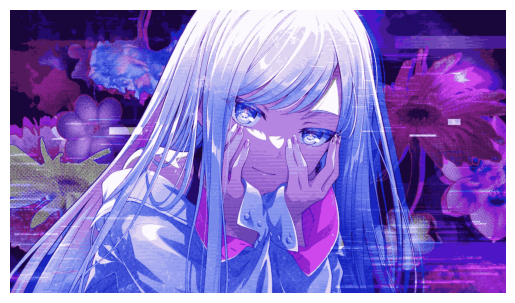

In [61]:
X = preprocess(img)
K = 20
kmeans = KMeans(n_clusters=K, random_state=1, n_init='auto').fit(X)
label = kmeans.predict(X)
img4 = np.zeros_like(X)
for k in range(K):
    img4[label == k] = kmeans.cluster_centers_[k]
img5 = img4.reshape((img.shape[0], img.shape[1], img.shape[2]))
print(kmeans.cluster_centers_)
plt.imshow(img5)
plt.axis('off')
plt.show() 

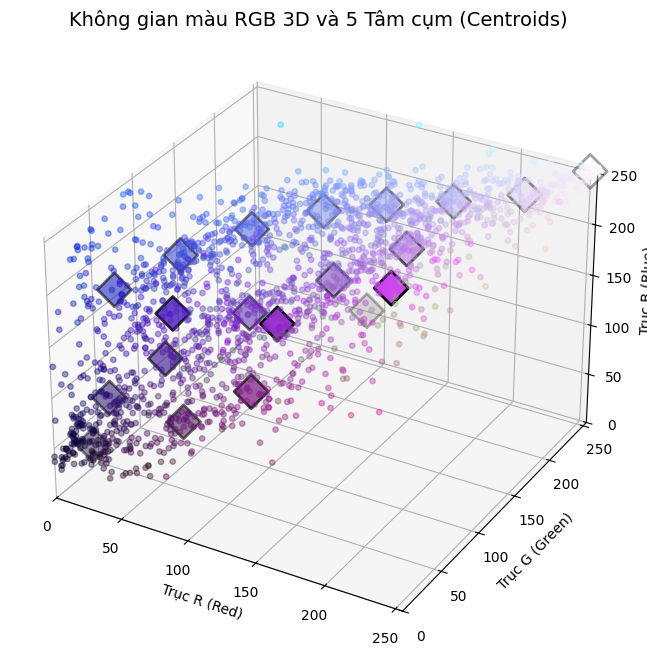

In [62]:
centroids = kmeans.cluster_centers_

# --- TIẾN HÀNH VẼ ĐỒ THỊ 3D ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# BƯỚC 1: Lấy mẫu (Sampling) để chống treo máy
# Lấy ngẫu nhiên 2000 điểm ảnh từ X để vẽ. Nếu X có ít hơn 2000, lấy tất cả.
sample_size = min(2000, X.shape[0])
indices = np.random.choice(X.shape[0], sample_size, replace=False)
X_sample = X[indices]

# BƯỚC 2: Chuẩn bị màu sắc thực tế
# Matplotlib yêu cầu màu RGB truyền vào phải ở dạng từ 0.0 đến 1.0 (thay vì 0-255)
# Nên ta chia toàn bộ mảng tọa độ cho 255.0
pixel_colors = X_sample / 255.0
centroid_colors = centroids / 255.0

# BƯỚC 3: Vẽ các pixel gốc lơ lửng trong không gian
# c=pixel_colors nghĩa là bắt mỗi điểm sáng lên đúng cái màu RGB của nó
ax.scatter(X_sample[:, 0], X_sample[:, 1], X_sample[:, 2], 
           c=pixel_colors, s=15, alpha=0.4)

# BƯỚC 4: Vẽ 5 Centroids (Tâm cụm)
# Dùng hình thoi lớn (marker='D'), kích thước 300, có viền đen dày để nổi bật giữa đám mây pixel
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], 
           c=centroid_colors, marker='D', s=300, edgecolor='black', linewidth=2)

# BƯỚC 5: Trang trí và thiết lập hệ tọa độ
ax.set_title('Không gian màu RGB 3D và 5 Tâm cụm (Centroids)', fontsize=14)
ax.set_xlabel('Trục R (Red)')
ax.set_ylabel('Trục G (Green)')
ax.set_zlabel('Trục B (Blue)')

# Ép hệ trục hiển thị cố định từ 0 đến 255 cho đúng bản chất RGB
ax.set_xlim([0, 255])
ax.set_ylim([0, 255])
ax.set_zlim([0, 255])

plt.show()